# Figure: SMT3 case study — PWM logo + nucleotide dependency maps

This figure tells the SMT3 / RPL43B locus story in two parts. **(A)** A masked DNA language model exposes *nucleotide dependency maps* — the in-silico "mutate position *i*, read the change at position *j*" analysis that reveals epistatic / structural couplings between bases at a yeast locus. **(B)** A conservation-weighted DNA sequence logo of the Shorkie-LM motif recovered for this region, rendered from the TF-MoDISco PWM.

**Reproduces:** the SMT3 PWM/DNA logo panel; the dependency-map panels come from the linked third-party notebook (Part A).

**Upstream:** the PWM logo reads a TF-MoDISco results HDF5 produced by `scripts/04_analysis/shorkie_lm/motif_analysis/motif_lm/` (the in-distribution Shorkie-LM tfmodisco run, `modisco_results_w16384_n100000.h5`), exposed as `config.get('results.modisco_lm')`. The dependency maps are produced by the third-party notebook documented in Part A.

**Requires:** `yeast_ml` conda env + `pip install -e .` for the PWM logo (Part B). The dependency-map notebook (Part A) needs a **separate** PyTorch / HuggingFace environment and a GPU — see its README. No GPU is needed for Part B.

**Source script:** `scripts/04_analysis/shorkie_lm/lm_SMT3_viz/2_viz_dna_pwm_shorkie_lm.py` (DNA-logo rendering) and `scripts/04_analysis/shorkie_lm/lm_SMT3_viz/dependency_map/` (Part A, linked not ported).

## Part A — Nucleotide dependency maps (third-party, separate environment)

The dependency-map panels are computed by a **stand-alone notebook** in this repo:

> `scripts/04_analysis/shorkie_lm/lm_SMT3_viz/dependency_map/compute_and_visualize_dep_maps_RPL43B.ipynb`
> (companion script: `compute_and_visualize_dep_maps_RPL43B.py`)

**What it does.** For a yeast locus (RPL43B, `chrX:607855-608355` on the R64 assembly), it loads a BERT-style masked DNA-LM (`johahi/specieslm-fungi-upstream-k1`), performs single-nucleotide saturation mutagenesis, and for every ordered pair of positions *(i, j)* measures how mutating *i* shifts the model's reconstructed probability at *j* (a log-odds effect). Taking the max absolute effect over the 4x4 nucleotide outcomes yields a position-by-position **dependency map** that highlights epistatic / structural couplings; the diagonal is zeroed.

**Method provenance (not ours).** The method and reference implementation are from the Gagneur lab — *"Nucleotide dependency analysis of DNA language models reveals genomic functional elements"* (repo `https://github.com/gagneurlab/dependencies_DNALM`, pinned commit `0a12361`, MIT (c) 2024). This directory holds only the Shorkie-specific, self-contained wrapper; the upstream package is deliberately not vendored.

**Why it is not run here.** It is a **PyTorch / HuggingFace** stack (`torch` 2.1, `transformers` 4.26, `flash-attn` 2.0.x, `datasets`, `biopython`) on an NVIDIA GPU — a different environment from the rest of Shorkie (TensorFlow / `baskerville`). It will **not** run in the `yeast_ml` env. Create a separate environment matching the upstream `requirements.txt` and open that notebook directly; only `from shorkie import config` (path resolution) is shared with this repo. We therefore **point to it rather than duplicate its code.**

The remaining cells reproduce **Part B only**: the Shorkie-LM SMT3 PWM / DNA logo.

## Part B — Shorkie-LM SMT3 PWM / DNA logo

We load the Shorkie-LM TF-MoDISco results, pick the SMT3 motif pattern, and render a conservation-weighted DNA sequence logo. The logo math (per-position entropy -> conservation `2 - H`, letters stacked by probability x conservation) and letter rendering are ported faithfully from `2_viz_dna_pwm_shorkie_lm.py::plot_dna_logo`, delegating the glyph drawing to `shorkie.helpers.yeast_helpers.dna_letter_at`.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from shorkie import config
from shorkie.helpers.yeast_helpers import dna_letter_at

2026-06-19 04:32:46.706181: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 04:32:46.750652: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 04:32:46.750684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 04:32:46.751973: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 04:32:46.759528: I tensorflow/core/platform/cpu_feature_guar

2026-06-19 04:32:47.851049: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Resolve the Shorkie-LM TF-MoDISco results HDF5 (no hardcoded paths).
# results.modisco_lm points at the in-distribution LM tfmodisco output dir;
# the per-architecture results file lives under <arch>/modisco_results_w16384_n100000.h5.
modisco_root = config.path('results.modisco_lm')
model_arch = 'unet_small_bert_drop'  # the published Shorkie-LM architecture
modisco_h5 = modisco_root / model_arch / 'modisco_results_w16384_n100000.h5'
print('TF-MoDISco results:', modisco_h5)
assert modisco_h5.exists(), (
    f'Missing {modisco_h5}. Run the upstream motif stage '
    'scripts/04_analysis/shorkie_lm/motif_analysis/motif_lm/ first, '
    'or point results.modisco_lm at your output.'
)

TF-MoDISco results: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/motif_LM/saccharomycetales_viz_seq/unet_small_bert_drop/modisco_results_w16384_n100000.h5


In [3]:
# Load the SMT3 motif PWM from the TF-MoDISco HDF5.
# Standard modisco layout: pos_patterns / neg_patterns -> pattern_<k> -> 'sequence' (PPM, L x 4 over A,C,G,T).
# Set SMT3_PATTERN to the pattern that maps to the SMT3 / RPL43B motif from the
# upstream modisco 'report' (TOMTOM/FIMO) annotation; pos_patterns/pattern_0 shown as a representative default.
SMT3_PATTERN = 'pos_patterns/pattern_0'

with h5py.File(modisco_h5, 'r') as f:
    pattern_grp = f[SMT3_PATTERN]
    pwm = np.array(pattern_grp['sequence'][:])  # (L, 4) probability matrix
print('SMT3 PWM shape:', pwm.shape)

SMT3 PWM shape: (30, 4)


In [4]:
def plot_dna_logo(pwm, figsize=(12, 3), logo_height=1.0, plot_start=0, plot_end=None):
    """Conservation-weighted DNA logo (ported from 2_viz_dna_pwm_shorkie_lm.py::plot_dna_logo).

    Letter height = probability x per-position conservation (2 - Shannon entropy);
    letters stacked smallest-to-largest. Glyphs drawn by shorkie's dna_letter_at.
    """
    if plot_end is None:
        plot_end = pwm.shape[0]
    pwm = np.copy(pwm[plot_start:plot_end, :]).astype(float)

    # Normalize each position to a probability distribution
    pwm += 1e-4
    pwm /= pwm.sum(axis=1, keepdims=True)

    # Per-position conservation = 2 - entropy
    entropy = np.zeros_like(pwm)
    entropy[pwm > 0] = pwm[pwm > 0] * -np.log2(pwm[pwm > 0])
    conservation = 2.0 - entropy.sum(axis=1)

    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    height_base = (1.0 - logo_height) / 2.0
    nts = ['A', 'C', 'G', 'T']

    for j in range(pwm.shape[0]):
        sort_index = np.argsort(pwm[j, :])  # smallest first
        for ii in range(4):
            i = sort_index[ii]
            nt_prob = pwm[j, i] * conservation[j]
            if ii == 0:
                y = height_base
            else:
                y = height_base + np.sum(pwm[j, sort_index[:ii]] * conservation[j]) * logo_height
            dna_letter_at(nts[i], j + 0.5, y, nt_prob * logo_height, ax)

    ax.set_xlim(0, plot_end - plot_start)
    ax.set_ylim(0, 2)
    ax.axhline(y=0.01 + height_base, color='black', linewidth=2)
    ax.axis('off')
    plt.tight_layout()
    return fig, ax

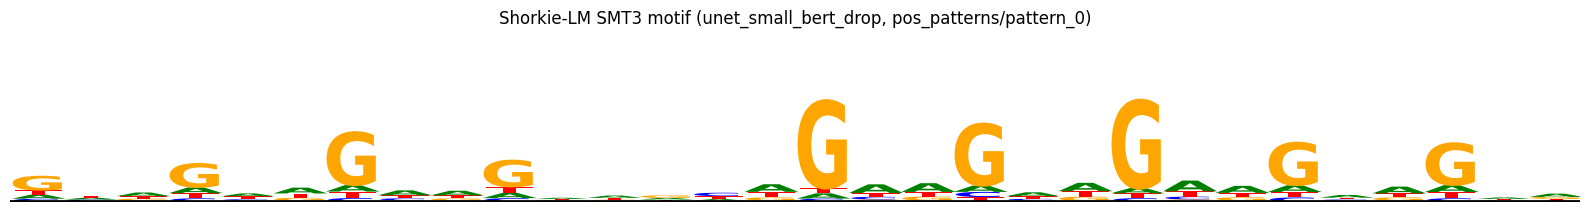

In [5]:
# Render the Shorkie-LM SMT3 DNA logo.
fig, ax = plot_dna_logo(pwm, figsize=(min(24, 0.4 * pwm.shape[0] + 4), 2))
ax.set_title(f'Shorkie-LM SMT3 motif ({model_arch}, {SMT3_PATTERN})')
plt.show()